In [1]:
!git clone https://github.com/expaetra/CM3070_final_project.git
%cd CM3070_final_project

Cloning into 'CM3070_final_project'...
remote: Enumerating objects: 218, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 218 (delta 52), reused 42 (delta 15), pack-reused 129 (from 1)
Receiving objects: 100% (218/218), 71.09 MiB | 10.34 MiB/s, done.
Resolving deltas: 100% (90/90), done.
Updating files: 100% (63/63), done.
/content/CM3070_final_project


## Capping overrrepresented disciplines

Then initial experiments showed that discipline classification does not perform as well as expected. Looking at the data distribution, we can see that a clear reason is class imbalance at the discipline level.

Artificial Intelligence is heavily overrepresented with 3499 samples, while most other disciplines contain significantly fewer samples. This creates a strong imbalance where one class dominates the dataset.

In contrast, the field labels are almost perfectly balanced and nearly all classes have 500 samples. This suggests that the issue might not be the task itself, but the uneven distribution of the discipline labels.

This imbalance means that the classifier is more likely to favor the dominant discipline, which can reduce performance on smaller classes.

This notebook applies a simple balancing strategy by capping the size of the Artificial Intelligence class.


In this experiment Artificial Intelligence is capped at 1000 samples. This value provides a balance between:
- reducing class imbalance
- preserving sufficient data for the largest discipline

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.corpus import stopwords

In [3]:
# load dataset

df = pd.read_csv("backend/data/arxiv_abstracts_cleaned.csv")
print(df.shape)
df.head()

(15717, 5)


,category,field,discipline,abstract,abstract_length
0,cs.LG,Machine Learning,Artificial Intelligence,design rule checking (drc) is getting increasi...,117
1,cs.LG,Machine Learning,Artificial Intelligence,anomaly detection is a key application of mach...,125
2,cs.LG,Machine Learning,Artificial Intelligence,the increased reliance on the internet and the...,220
3,cs.LG,Machine Learning,Artificial Intelligence,clinical coding is an administrative process t...,159
4,cs.LG,Machine Learning,Artificial Intelligence,the translation of medical diagnosis to clinic...,154


In [4]:
# show distribution

discipline_counts = df['discipline'].value_counts()
field_counts = df['field'].value_counts()
print("Discipline:\n", discipline_counts)
print("\nField:\n", field_counts)

Discipline:
 discipline
Artificial Intelligence         3445
Theory of Computation           1436
Multimedia                       994
World Wide Web                   992
Computer Systems                 991
Distributed Systems              500
Computer Imaging and Vision      499
Robotics                         498
Computational Science            498
Information Retrieval            498
Cybersecurity                    497
Emerging Technologies            494
Human-Computer Interaction       494
Social Computing                 493
Computer Hardware                492
Software Engineering             490
Computer Networks                489
Communication                    488
Computer Programming             485
Computer Graphics                484
Theoretical Computer Science     460
Name: count, dtype: int64

Field:
 field
Machine Learning                        500
Distributed Computer Systems            500
Natural Language Processing             499
Computer Vision           

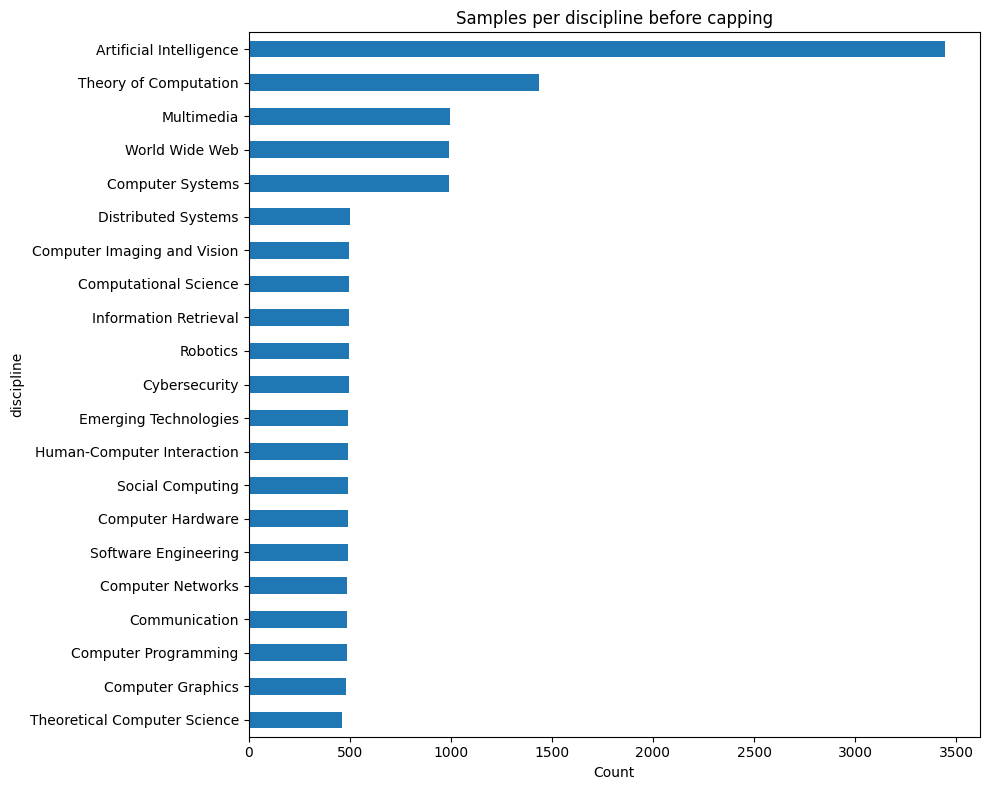

In [5]:
# visualization
plt.figure(figsize=(10, 8))
discipline_counts.sort_values().plot(kind='barh')
plt.title('Samples per discipline before capping')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [6]:
# apply cap

ai_cap = 1000

ai_subset = df[df['discipline']=='Artificial Intelligence'].sample(
    n=ai_cap,
    random_state=42
)

other = df[df['discipline'] != 'Artificial Intelligence']
df_capped = pd.concat([other, ai_subset], axis=0)
df_capped = df_capped.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_capped['discipline'].value_counts())

discipline
Theory of Computation           1436
Artificial Intelligence         1000
Multimedia                       994
World Wide Web                   992
Computer Systems                 991
Distributed Systems              500
Computer Imaging and Vision      499
Robotics                         498
Information Retrieval            498
Computational Science            498
Cybersecurity                    497
Human-Computer Interaction       494
Emerging Technologies            494
Social Computing                 493
Computer Hardware                492
Software Engineering             490
Computer Networks                489
Communication                    488
Computer Programming             485
Computer Graphics                484
Theoretical Computer Science     460
Name: count, dtype: int64


In [7]:
# stopwords

nltk.download("stopwords")

custom_stops = {
    'based', 'paper', 'show', 'results', 'problem', 'using', 'approach',
    'proposed', 'method', 'methods', 'propose', 'present', 'work',
    'used', 'use', 'two', 'one', 'new', 'also', 'shows', 'however',
    'provide', 'study', 'task', 'tasks', 'different', 'high', 'given'
}
stop_words = set(stopwords.words('english')).union(custom_stops)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [8]:
# prepare data

X_text = df_capped["abstract"].astype(str)
y_disc = df_capped["discipline"]

In [9]:
# train/test split

X_train_text, X_test_text, y_train,y_test = train_test_split(
    X_text,
    y_disc,
    test_size=0.2,
    random_state=42,
    stratify=y_disc
)
print("Train:", len(X_train_text))
print("Test:", len(X_test_text))

Train: 10617
Test: 2655


In [10]:
# TF-IDF (best representation from earlier experiments)

vectorizer = TfidfVectorizer(
    stop_words=list(stop_words),
    ngram_range=(1, 1),
    max_features=5000
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [11]:
# train the logistic regression model

model = LogisticRegression(max_iter=1000,random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [12]:
# evaluation

# calculate macro-averaged precision, recall, F1
accuracy = accuracy_score(y_test, y_pred)
macro_p, macro_r, macro_f1, _ =precision_recall_fscore_support(
    y_test, y_pred, average='macro', zero_division=0
)

# calculate weighted averaged precision, recall, F1
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='weighted', zero_division=0
)

print("Accuracy:", round(accuracy, 3))
print("Macro F1:", round(macro_f1, 3))
print("Weighted F1:", round(weighted_f1, 3))

Accuracy: 0.577
Macro F1: 0.564
Weighted F1: 0.573


In [13]:
results = {
    "task": "Discipline",
    "accuracy": accuracy,
    "macro_precision": macro_p,
    "macro_recall": macro_r,
    "macro_f1": macro_f1,
    "weighted_precision": weighted_p,
    "weighted_recall": weighted_r,
    "weighted_f1": weighted_f1
}

df_results = pd.DataFrame([results])
df_results

,task,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Discipline,0.577024,0.588381,0.549847,0.564219,0.580282,0.577024,0.573254


In [14]:
# save
import os
os.makedirs("/content/drive/MyDrive/CM3070_final_project/backend/data", exist_ok=True)
# save dataset
df_capped.to_csv(
    "/content/drive/MyDrive/CM3070_final_project/backend/data/capped_disciplines.csv",
    index=False
)

# save results
df_results.to_csv(
    "/content/drive/MyDrive/CM3070_final_project/backend/data/capped_discipline_results.csv",
    index=False
)

print("Saved")

Saved
